In [30]:
100*(2/8)

25.0

In [24]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

# Load CSV
df = pd.read_csv('../errors_with_status.csv')

# Build ann1 from 'status' column
ann1 = df['status'].tolist()

# Make a copy for ann2
ann2 = ann1.copy()

# Flags to ensure only one change per rule
change1_done = False
change2_done = False
change3_done = False

# Single loop to apply all changes safely
for i, val in enumerate(ann2):
    # 1. Replace 1 instance of "hallucinated and incorrect" with "hallucinated and corrected"
    if not change1_done and val == "hallucinated and corrected" and ann1[i] == "hallucinated and corrected":
        ann2[i] = "hallucinated and incorrect"
        change1_done = True
        print("Changed entry", i, "from 'hallucinated and corrected' to 'hallucinated and incorrect'")
        continue  # skip to next iteration

    # 2. Replace 1 instance of "hallucinated and incorrect" with "preserved"
    # Only consider original values from ann1, not ones already changed
    if not change2_done and val == "preserved" and ann1[i] == "preserved":
        ann2[i] = "hallucinated and incorrect"
        change2_done = True
        print("Changed entry", i, "from 'preserved' to 'hallucinated and incorrect'")
        continue

    # 3. Replace 1 instance of "preserved" with "hallucination but correct"
    # Only consider original values from ann1
    if not change3_done and val == "hallucinated and corrected" and ann1[i] == "hallucinated and corrected":
        ann2[i] = "preserved"
        change3_done = True
        print("Changed entry", i, "from 'hallucinated and correct' to 'preserved'")
        continue


kappa = cohen_kappa_score(ann1, ann2)

print(f"Cohen's Kappa: {kappa:.4f}")

Changed entry 0 from 'hallucinated and corrected' to 'hallucinated and incorrect'
Changed entry 1 from 'preserved' to 'hallucinated and incorrect'
Changed entry 2 from 'hallucinated and correct' to 'preserved'
Cohen's Kappa: 0.8866


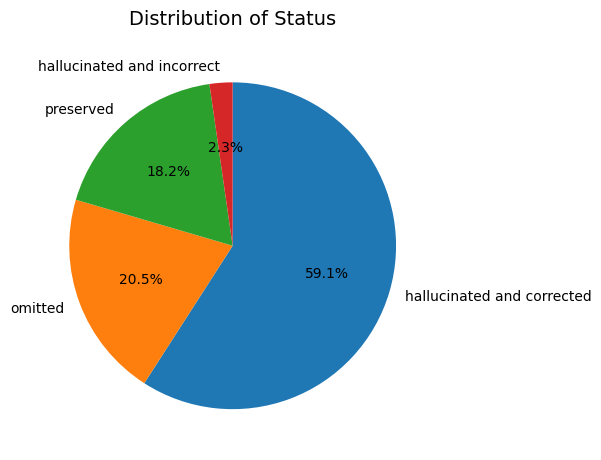

/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_94892/2441634273.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["section", "status"])


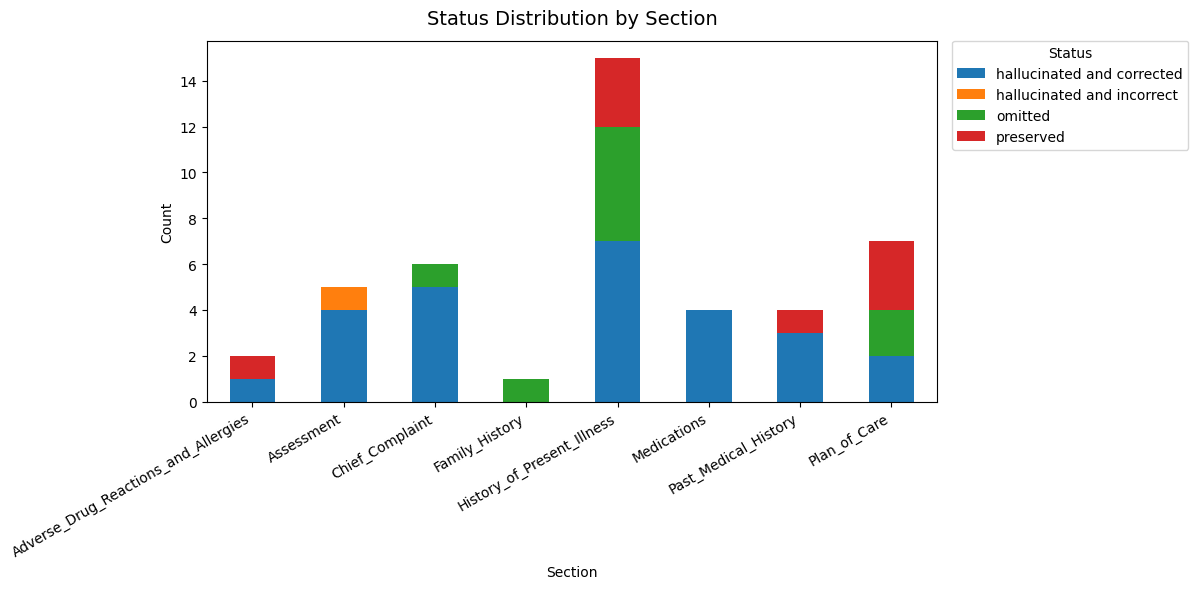

/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_94892/2441634273.py:95: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["status", "error_type"])
/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_94892/2441634273.py:106: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["error_type", "status"])


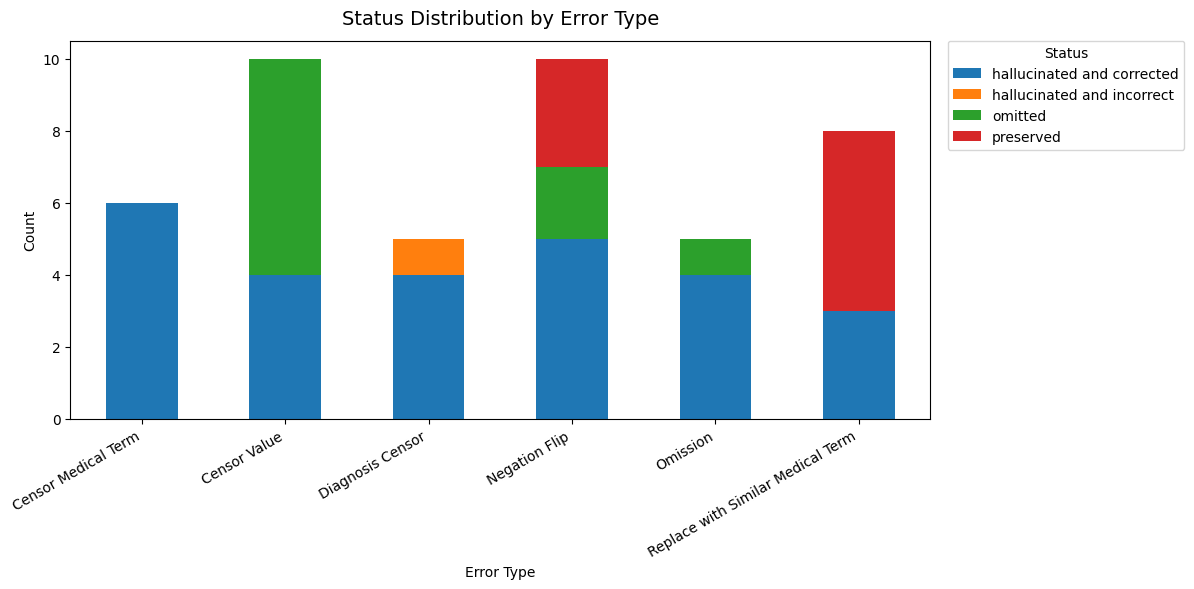

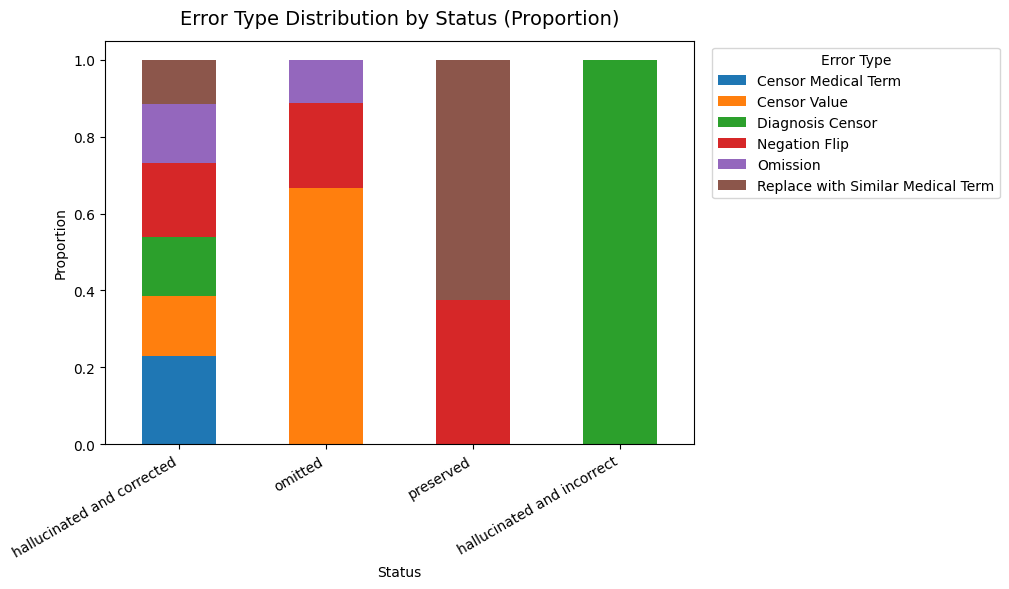

/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_94892/2441634273.py:160: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["section", "error_type", "status"])
/var/folders/95/v1w_5gps1tv7kdq9zxkwrb980000gn/T/ipykernel_94892/2441634273.py:165: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for section, subdf in status_by_section_error.groupby(level=0):


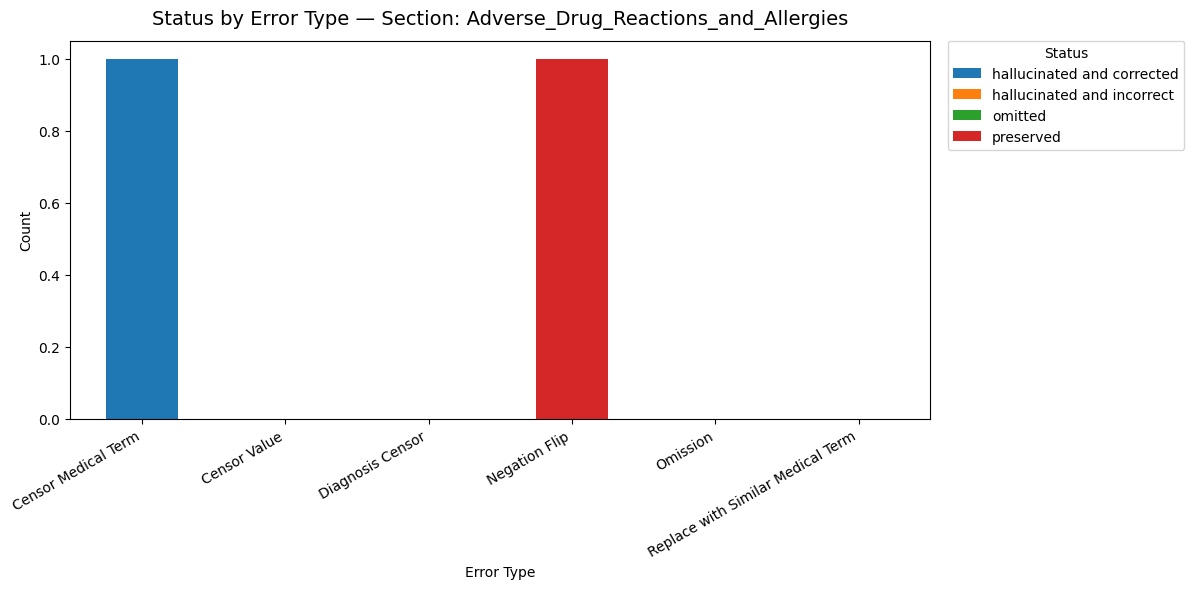

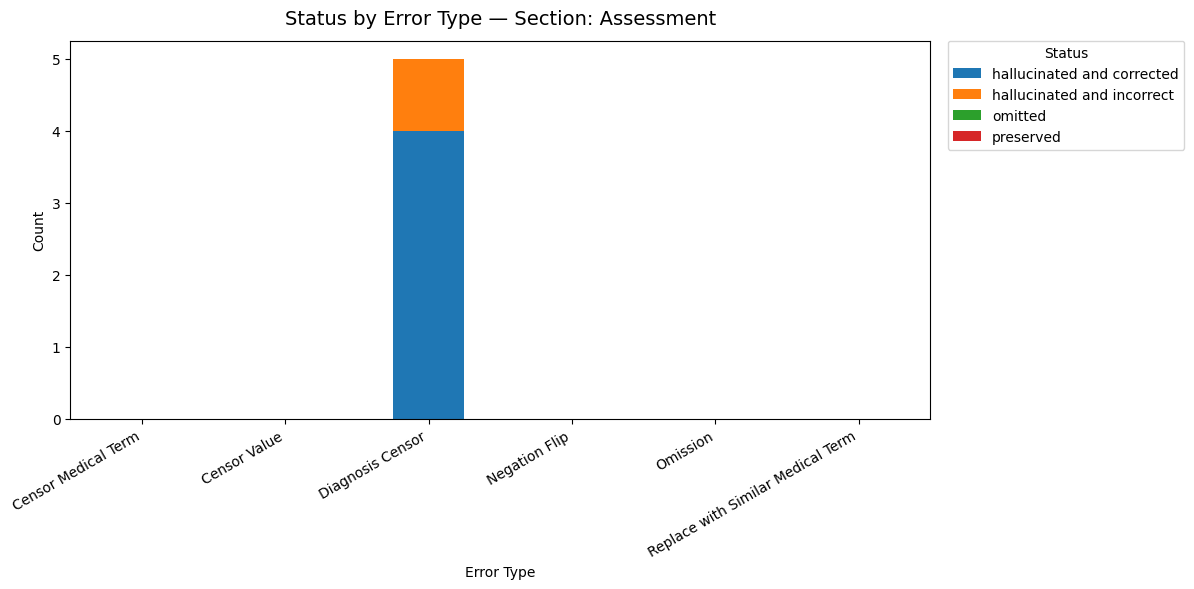

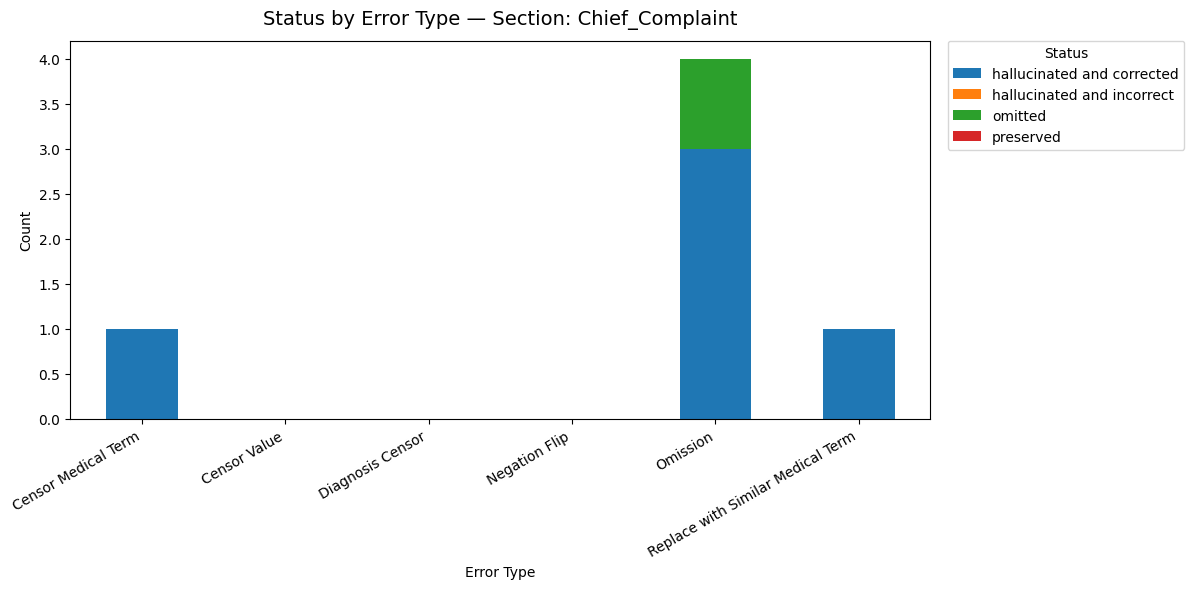

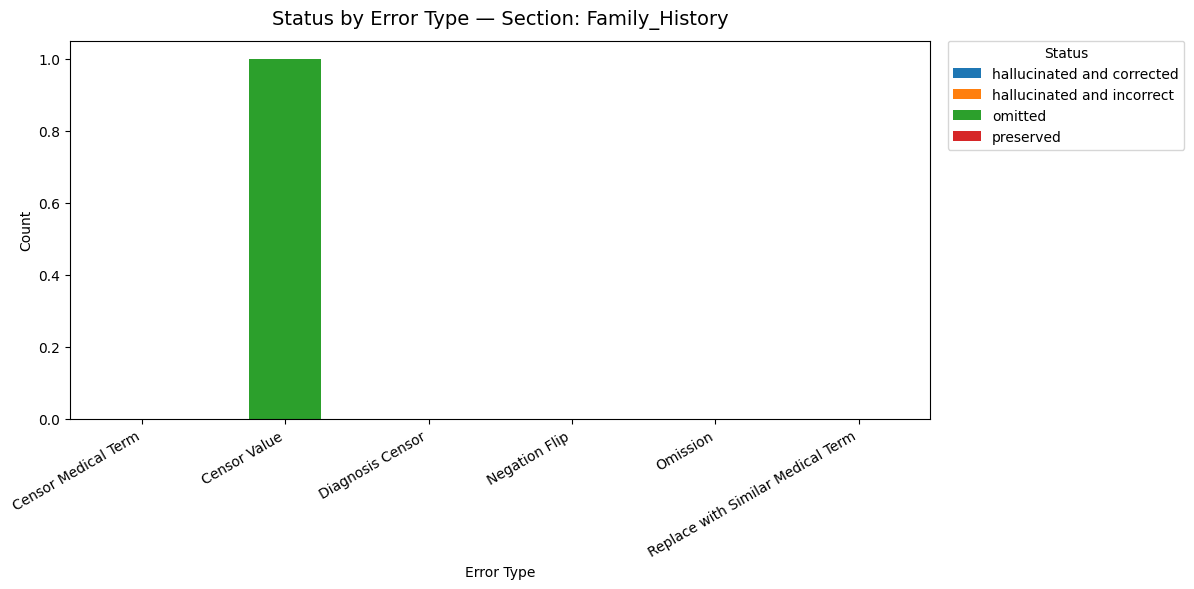

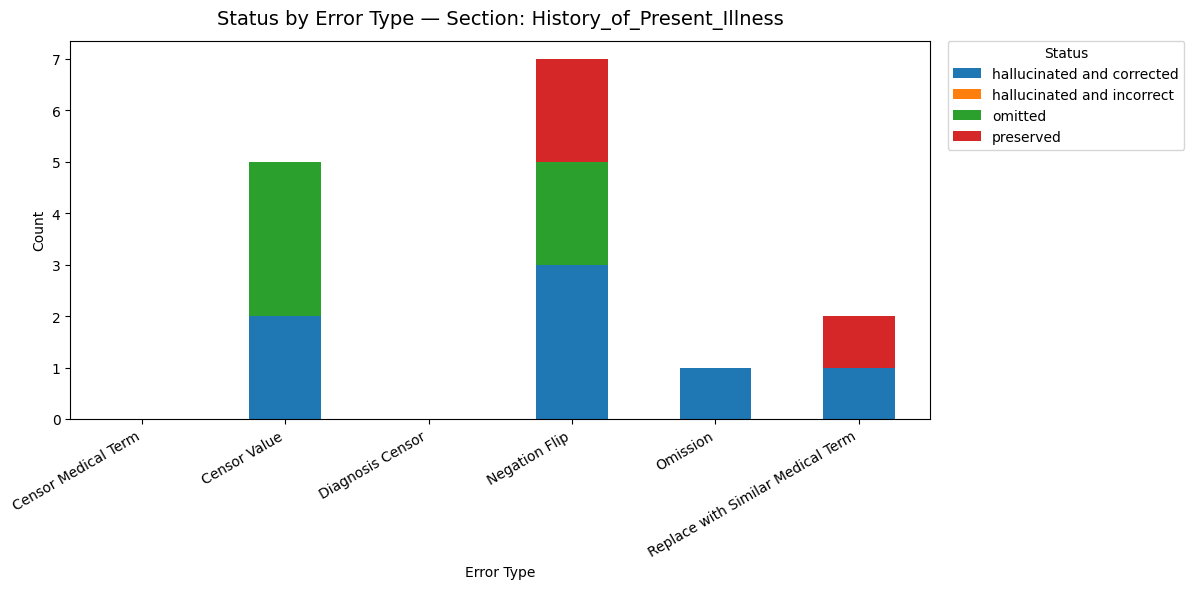

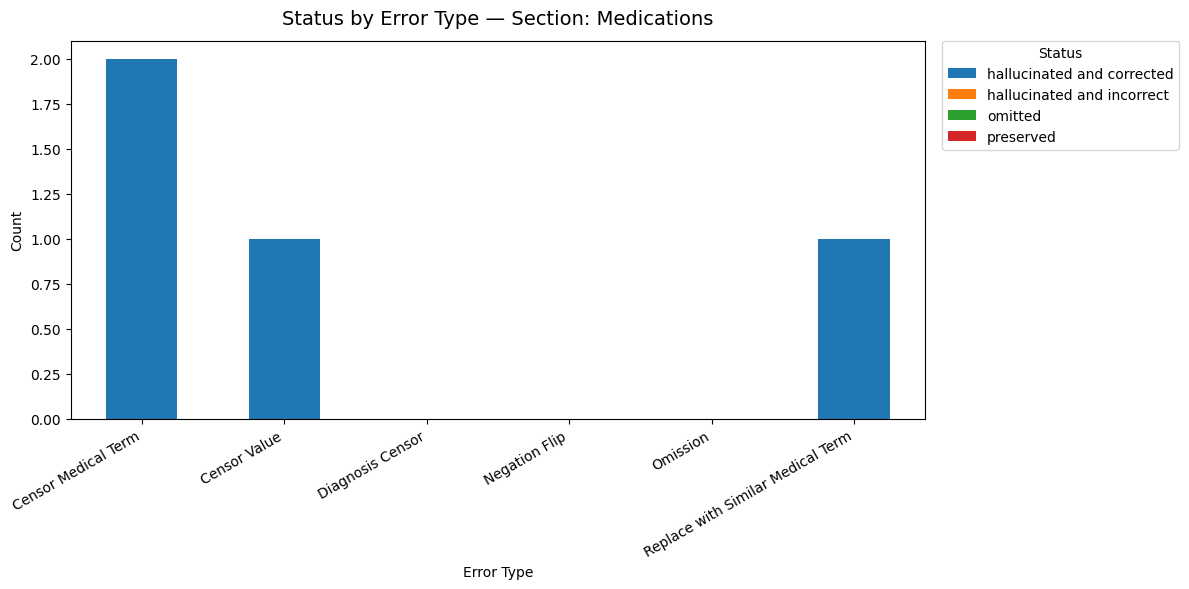

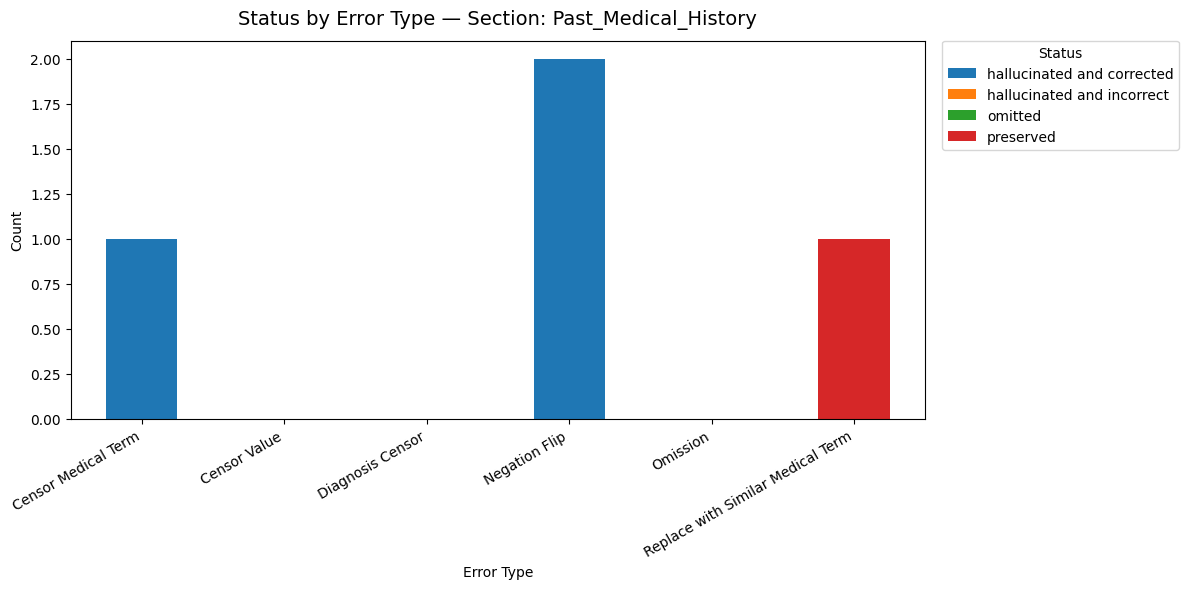

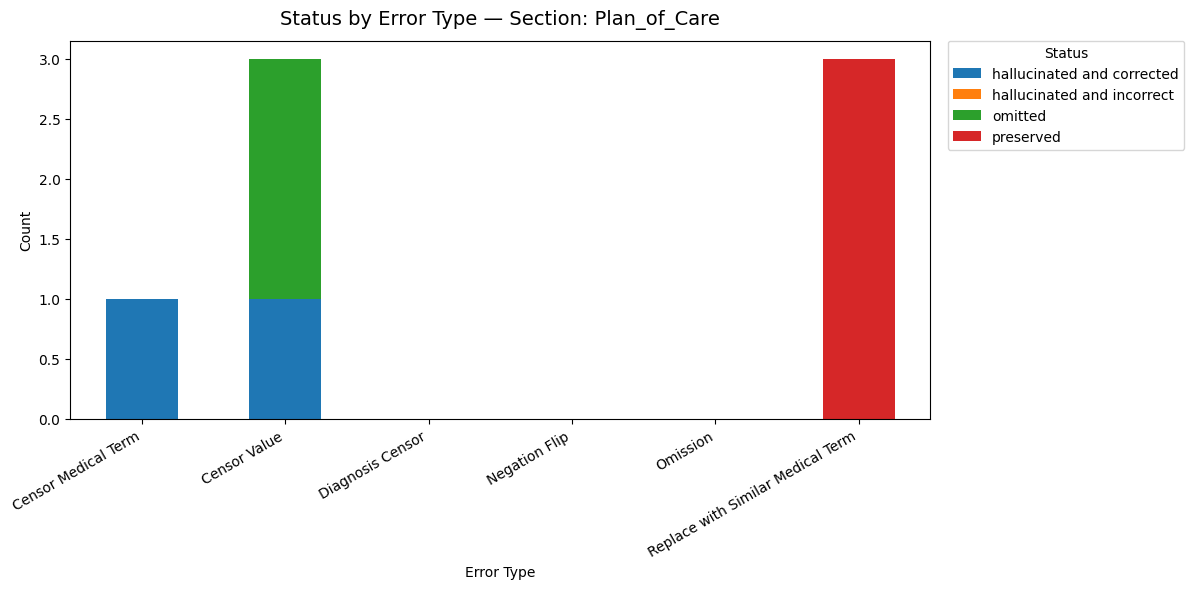

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Load data
# -------------------------
df = pd.read_csv("../errors_with_status.csv")

# Ensure categorical columns
cols = ["status", "section", "error_type"]
for c in cols:
    df[c] = df[c].astype("category")

# Optional: consistent ordering
df["status"] = df["status"].cat.as_ordered()

# -------------------------
# Helper plotting function
# -------------------------
def plot_stacked_bar(
    df,
    title,
    xlabel,
    ylabel="Count",
    figsize=(10, 6),
    rotate_xticks=30
):
    ax = df.plot(
        kind="bar",
        stacked=True,
        figsize=figsize
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=rotate_xticks,
        ha="right"
    )

    # Legend outside plot
    ax.legend(
        title="Status",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()

# -------------------------
# 1. Overall distribution of status
# -------------------------
# Count status
status_counts = df["status"].value_counts()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)

plt.title("Distribution of Status", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

# -------------------------
# 2. Status stratified by section
# -------------------------
status_by_section = (
    df.groupby(["section", "status"])
      .size()
      .unstack(fill_value=0)
)

plot_stacked_bar(
    status_by_section,
    title="Status Distribution by Section",
    xlabel="Section",
    figsize=(12, 6)
)

# -------------------------
# 3. Status stratified by error_type
# -------------------------
status_error_counts = (
    df.groupby(["status", "error_type"])
      .size()
      .unstack(fill_value=0)
)

# Optional: sort status by total count
status_error_counts = status_error_counts.loc[
    status_error_counts.sum(axis=1).sort_values(ascending=False).index
]

status_by_error_type = (
    df.groupby(["error_type", "status"])
      .size()
      .unstack(fill_value=0)
)

plot_stacked_bar(
    status_by_error_type,
    title="Status Distribution by Error Type",
    xlabel="Error Type",
    figsize=(12, 6)
)


# Ensure categorical
df["status"] = df["status"].astype("category")
df["error_type"] = df["error_type"].astype("category")

status_error_props = status_error_counts.div(
    status_error_counts.sum(axis=1),
    axis=0
)

fig, ax = plt.subplots(figsize=(10, 6))

status_error_props.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title("Error Type Distribution by Status (Proportion)", fontsize=14, pad=12)
ax.set_xlabel("Status")
ax.set_ylabel("Proportion")

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    ha="right"
)

ax.legend(
    title="Error Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# -------------------------
# 4. Status stratified by BOTH section and error_type
# -------------------------
status_by_section_error = (
    df.groupby(["section", "error_type", "status"])
      .size()
      .unstack(fill_value=0)
)

for section, subdf in status_by_section_error.groupby(level=0):
    subdf = subdf.droplevel(0)

    plot_stacked_bar(
        subdf,
        title=f"Status by Error Type — Section: {section}",
        xlabel="Error Type",
        figsize=(12, 6)
    )
